In [1]:
# import libraries 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 
# Visual formatting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
COLOR_PRIMARY = '#1f77b4'
COLOR_ALERT = '#d62728'
COLOR_NEUTRAL = '#7f7f7c'


# Load Dataset

In [3]:
df=pd.read_csv("heart_2020_cleaned.csv")
df=pd.DataFrame(df)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


# Data Quality and structural Audit 

In [4]:
# Check missing values, data types, and initial sample
print("--- Data Info ---")
df.info()

print("\n--- Missing Values Audit ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n--- Sample Records ---")
df.head()

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [16]:
# Check missing values, data types, and initial sample
print("--- Data Info ---")
df.info()

print("\n--- Missing Values Audit ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n--- Sample Records ---")
df.head()

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [12]:
# Check the distribution of the target variable
healthy = (df["HeartDisease"]=="No").sum()
heart_patients = (df["HeartDisease"]=="Yes").sum()
print(f"Number of healthy individuals: {healthy}")
print(f"Number of individuals with heart disease: {heart_patients}")
Total = healthy + heart_patients
print(f"Percentage of healthy individuals: {healthy/Total*100:.2f}%")
print(f"percentage of individuals with heart disease: {heart_patients/Total*100:.2f}%")

Number of healthy individuals: 292422
Number of individuals with heart disease: 27373
Percentage of healthy individuals: 91.44%
percentage of individuals with heart disease: 8.56%


## 1. Data Quality & Target Distribution Analysis

### Key Audit Findings:
- **Completeness:** The dataset contains zero missing values across 319,795 rows.
- **Features:** 18 total variables (4 numerical, 14 categorical/binary).
- **Target Variable (`HeartDisease`):** Severe class imbalance exists. Only ~8.5% of respondents report heart disease.

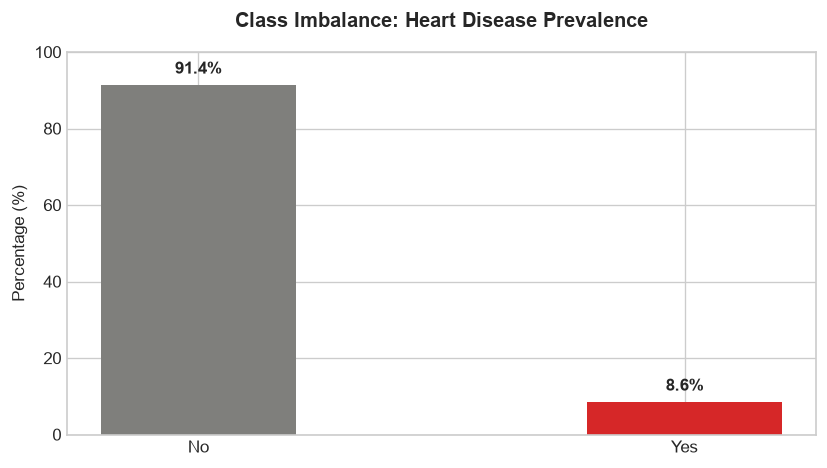

In [ ]:
# Target distribution check
target_counts = df['HeartDisease'].value_counts()
target_pcts = df['HeartDisease'].value_counts(normalize=True) * 100 

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(target_pcts.index, target_pcts.values, color=[COLOR_NEUTRAL, COLOR_ALERT], width=0.4)

ax.set_title("Class Imbalance: Heart Disease Prevalence", fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel("Percentage (%)", fontsize=10)
ax.set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Helper Plotting Function for Prevalence
def plot_heart_disease_prevalence(data, feature, title, xlabel, order=None, rotation=0):
    """
    Calculates and plots the percentage of HeartDisease == 'Yes' across feature categories
    to account for target class imbalance.
    """
    prevalence = (
        data.groupby(feature)['HeartDisease']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index()
        .rename(columns={'HeartDisease': 'Prevalence_%'})
    )
    
    if order:
        prevalence[feature] = pd.Categorical(prevalence[feature], categories=order, ordered=True)
        prevalence = prevalence.sort_values(feature)
        
    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(data=prevalence, x=feature, y='Prevalence_%', color=COLOR_ALERT)
    
    plt.title(title, fontsize=12, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel("Heart Disease Prevalence (%)", fontsize=10)
    plt.xticks(rotation=rotation)
    
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f"{height:.1f}%",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                        textcoords='offset points', fontweight='bold')
            
    plt.tight_layout()
    plt.show()

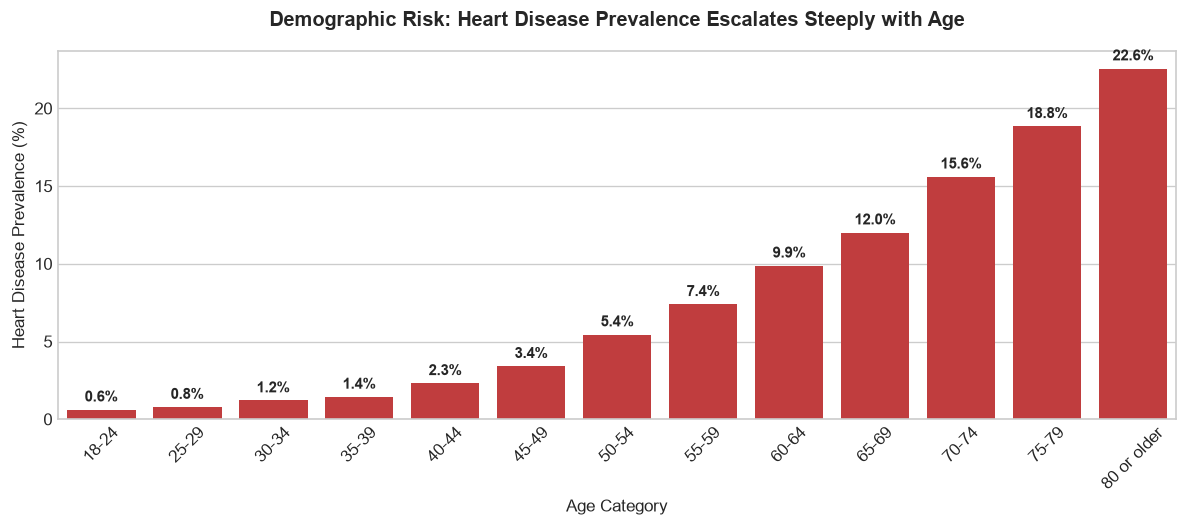

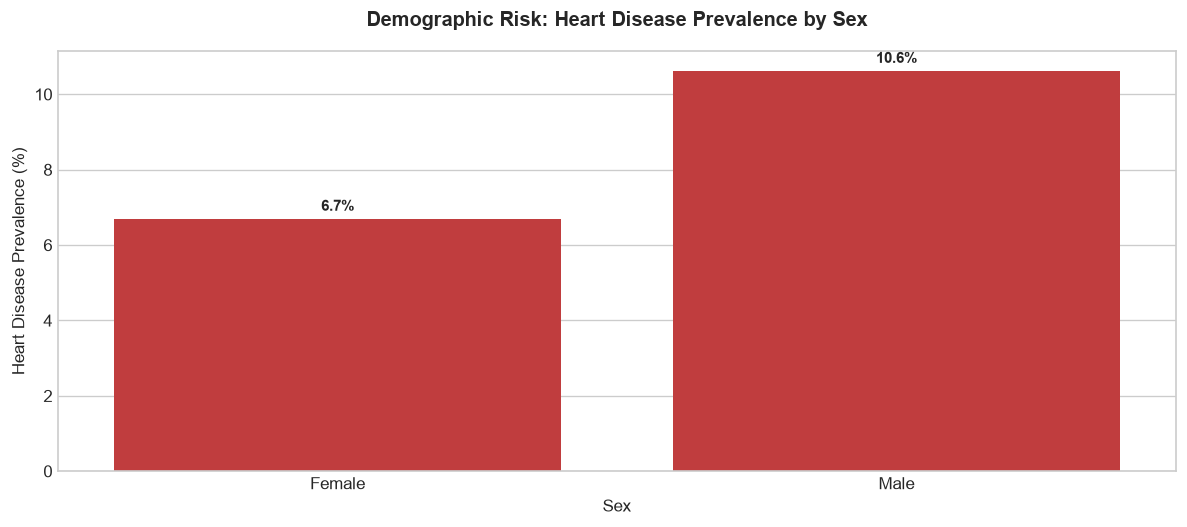

In [15]:
# Demographic Risk Analysis (Age, Sex, Race)
# Age Category Order
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
             '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']

# Age Risk Progression
plot_heart_disease_prevalence(
    df, 'AgeCategory', 
    title="Demographic Risk: Heart Disease Prevalence Escalates Steeply with Age", 
    xlabel="Age Category", 
    order=age_order, 
    rotation=45
)

# Sex Risk Comparison
plot_heart_disease_prevalence(
    df, 'Sex', 
    title="Demographic Risk: Heart Disease Prevalence by Sex", 
    xlabel="Sex"
)

## 2. Demographic Risk Takeaways
- **Age is the single strongest demographic predictor:** Risk increases non-linearly, starting below 1.5% for ages 18–39 and peaking at **22.5%** in individuals aged 80+.
- **Gender Disparity:** Males present a higher risk rate (~10.6%) compared to females (~6.7%).

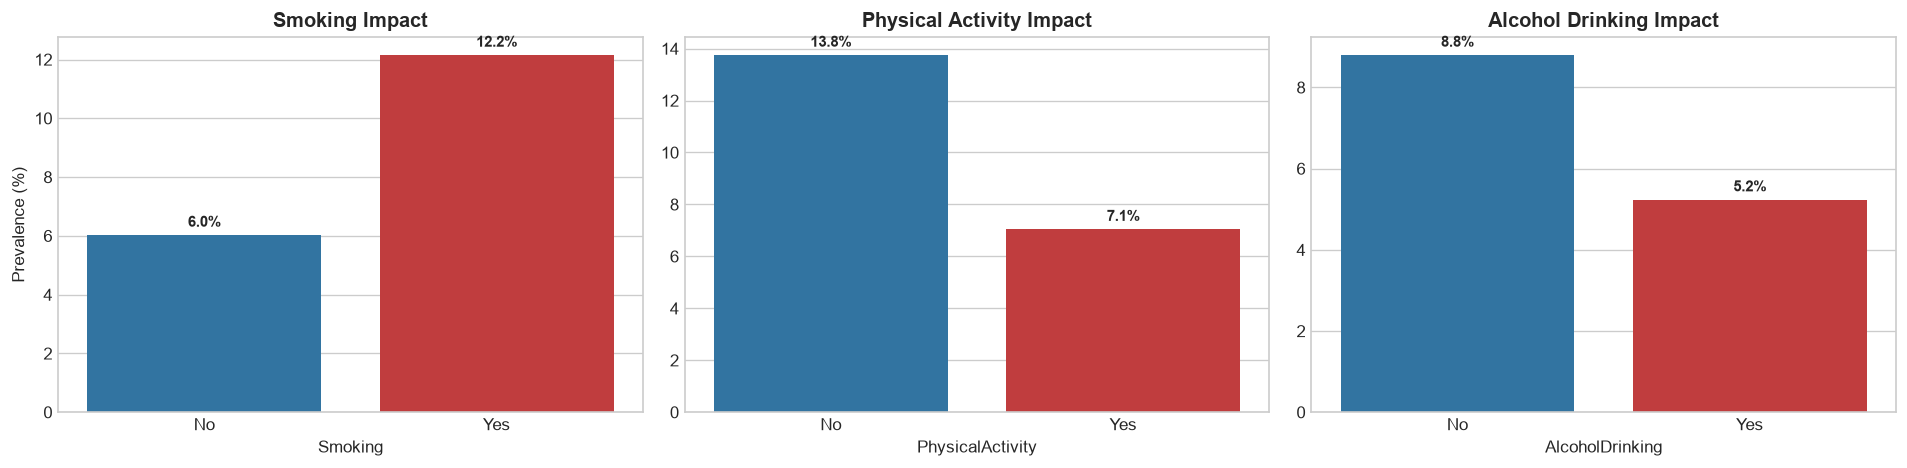

In [16]:
# Lifestyle Drivers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lifestyle_vars = ['Smoking', 'PhysicalActivity', 'AlcoholDrinking']
titles = ['Smoking Impact', 'Physical Activity Impact', 'Alcohol Drinking Impact']

for i, var in enumerate(lifestyle_vars):
    prev = df.groupby(var)['HeartDisease'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    sns.barplot(data=prev, x=var, y='HeartDisease', ax=axes[i], palette=[COLOR_PRIMARY, COLOR_ALERT])
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_ylabel("Prevalence (%)" if i == 0 else "")
    axes[i].set_xlabel(var)
    
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(f"{height:.1f}%",
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

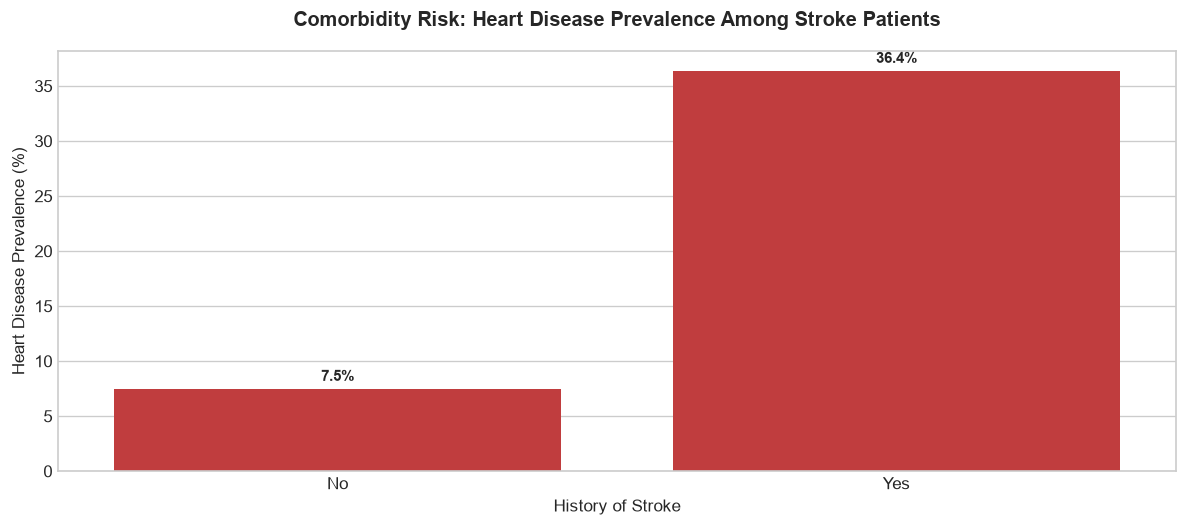

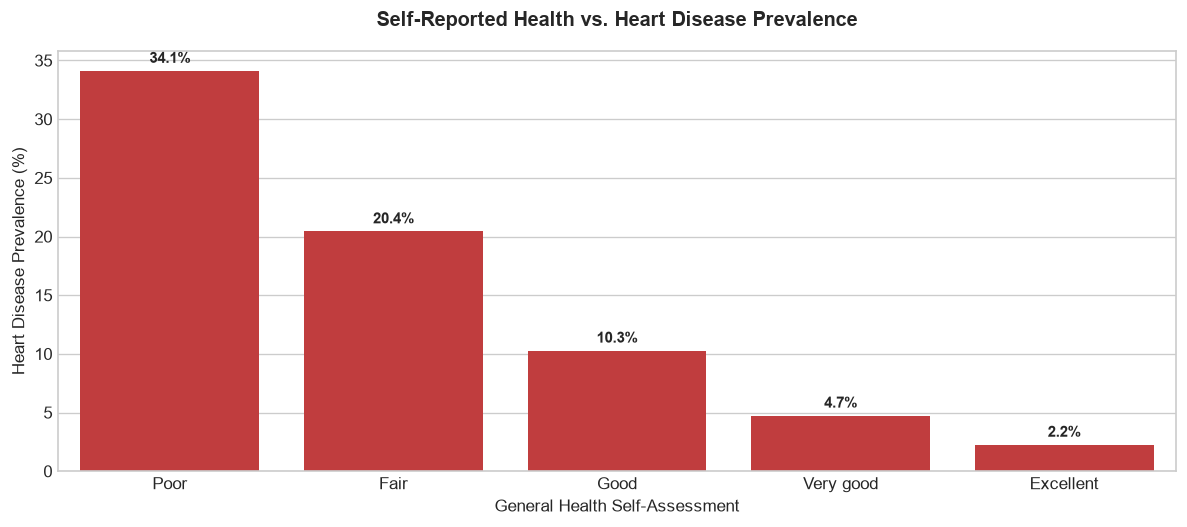

In [17]:
# Comorbidity Impact
plot_heart_disease_prevalence(
    df, 'Stroke', 
    title="Comorbidity Risk: Heart Disease Prevalence Among Stroke Patients", 
    xlabel="History of Stroke"
)

gen_health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
plot_heart_disease_prevalence(
    df, 'GenHealth', 
    title="Self-Reported Health vs. Heart Disease Prevalence", 
    xlabel="General Health Self-Assessment",
    order=gen_health_order
)

Numerical Distribution Analysis & Correlation Heatmap

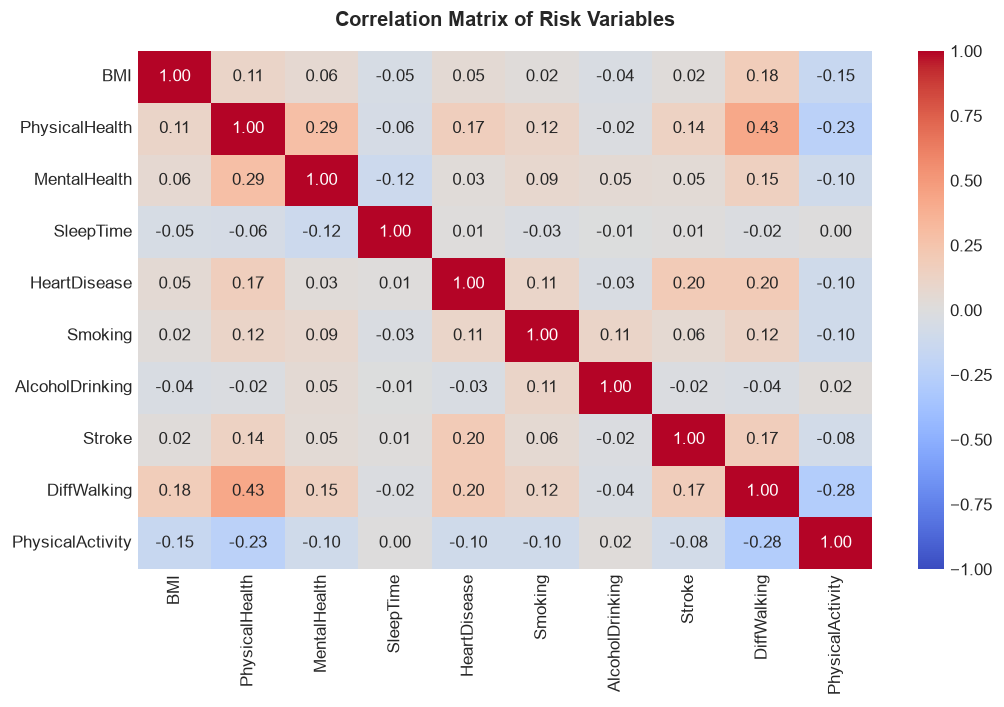

In [18]:
# Prepare binary numeric mapping for correlation analysis
numeric_df = df[['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']].copy()

binary_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'PhysicalActivity']
for col in binary_cols:
    numeric_df[col] = (df[col] == 'Yes').astype(int)

# Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Correlation Matrix of Risk Variables", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

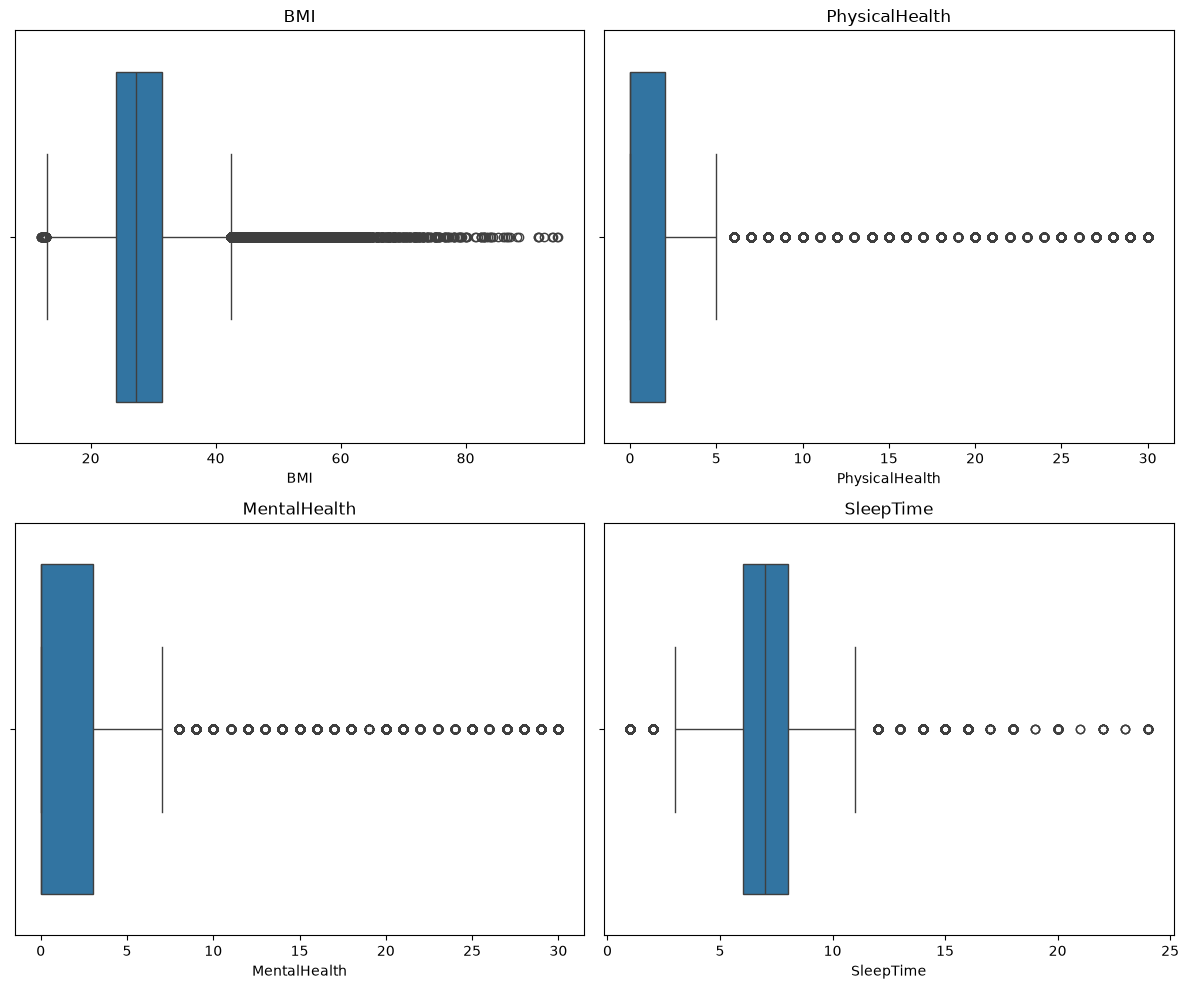

In [4]:
# visualization of outliers in four columns using boxplot
fig, ax=plt.subplots(2,2, figsize=(12,10))
ax[0,0].set_title('BMI')
ax[0,1].set_title('PhysicalHealth')
ax[1,0].set_title('MentalHealth')
ax[1,1].set_title('SleepTime')
sns.boxplot(x='BMI', data=df, ax=ax[0,0])
sns.boxplot(x='PhysicalHealth', data=df, ax=ax[0,1])
sns.boxplot(x='MentalHealth', data=df, ax=ax[1,0])
sns.boxplot(x='SleepTime', data=df, ax=ax[1,1])
plt.tight_layout()

In [8]:
numeric_columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object","str"]).columns.tolist()
numeric_columns
print(f"Numeric columns: {numeric_columns}")
print(f"Categorical columns: {categorical_columns}")

Numeric columns: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical columns: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


<Axes: xlabel='MentalHealth', ylabel='HeartDisease'>

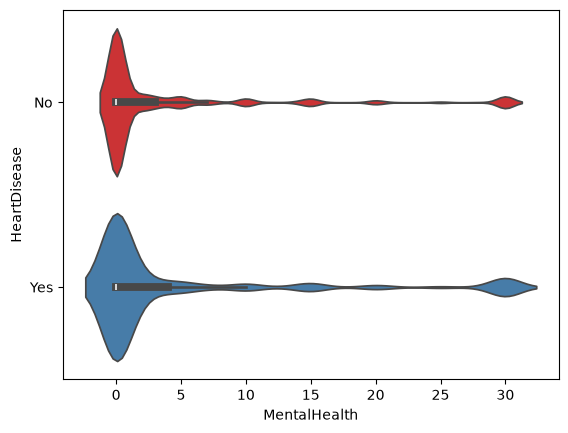

In [15]:
sns.violinplot(x='MentalHealth', y='HeartDisease', data=df, palette='Set1')

## Executive Summary & Strategic Recommendations

### Core Findings
1. **Strongest Predictors:** Age category, history of **Stroke** (36.4% prevalence among stroke survivors vs. 7.5% without), **Difficulty Walking**, and **Diabetic status**.
2. **Behavioral Impact:** Smokers display a ~12.1% risk rate compared to ~6.0% for non-smokers (double the risk). Regular physical activity reduces prevalence from ~13.8% to ~7.8%.
3. **Class Imbalance Consideration:** Heart disease affects 8.5% of the overall survey population. Models evaluated purely on overall accuracy will fail to capture positive cases.

### Actionable Next Steps for Analytics & ML Pipeline
1. **Target Metric Selection:** Prioritize **PR-AUC (Precision-Recall Area Under Curve)** and **Recall** rather than raw Accuracy or ROC-AUC during model training.
2. **Feature Engineering:**
   - Create a composite `Mobility_Risk_Index` combining `DiffWalking` and `PhysicalHealth`.
   - Engineer an `Age_Comorbidity_Interaction` feature pairing `AgeCategory` with `Diabetic` and `Stroke` flags.
3. **Resampling / Class Balancing:** Apply **SMOTE** or class weight adjustments (`class_weight='balanced'`) during predictive model development.